# PPP full version
- v2 (July/5/2023)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import seaborn as sns
import colorcet as cc
import collections
import sys
import multiprocessing

from IPython.display import clear_output
from matplotlib.path import Path
from astropy import units as u
from astropy.coordinates import SkyCoord,Angle
from astropy.table import Table,vstack
from itertools import chain
from sklearn.cluster import DBSCAN,AgglomerativeClustering
from sklearn.neighbors import KernelDensity
from functools import partial
import scipy.optimize as opt

import warnings
warnings.filterwarnings('ignore')

#below for netflow
from __future__ import print_function
import ets_fiber_assigner.netflow as nf
from ics.cobraOps.Bench import Bench
from ics.cobraOps.TargetGroup import TargetGroup
from ics.cobraOps.CobrasCalibrationProduct import CobrasCalibrationProduct
from ics.cobraOps.CollisionSimulator import CollisionSimulator
from ics.cobraOps.cobraConstants import NULL_TARGET_POSITION, NULL_TARGET_ID
from ics.cobraOps import plotUtils
from collections import defaultdict

# read samples

In [12]:
def DBconnect(dialect,user,pwd,host,port,dbname):
    '''create the link of DB to connect 
    
    Parameters
    ==========
    dialect,user,pwd,host,port,dbname : string

    Returns
    =======
    the link of DB to connect 
    '''
    return "{0}://{1}:{2}@{3}:{4}/{5}".format(dialect,user,pwd,host,port,dbname)

def readUserSample(para,Print=True):
    '''Read target list including: 
       'ob_code' 'ra' 'dec' 'equinox' 'priority' 'exptime' 'resolution' 'proposal_id' 'rank' 'grade'

    Parameters
    ==========
    para : dict
        mode: 
            'local' -- read target list from local machine
            'db' -- read target list from Database
            
        localPath:
            (if mode == local) the path of the target list
        dialect,user,pwd,host,port,dbname:
            (if mode == db) used to create the link to connect DB
        sql_query:
            (if mode == db) used to query necessary information of targets from DB

    Returns
    =======
    target sample (all), target sample (low-resolution mode), target sample (medium-resolution mode)
    '''
    time_start=time.time()
        
    if para['mode'] == 'local':
        uSamp=Table.read(para['localPath']) 
        
    elif para['mode'] == 'db':
        import pandas as pd
        import psycopg2
        import sqlalchemy as sa
        
        DBads=DBconnect(para['dialect'],para['user'],para['pwd'],para['host'],para['port'],para['dbname'])
        tgtDB = sa.create_engine(DBads)
        
        sql = para['sql_query']
        
        conn = tgtDB.connect()
        query = conn.execute(sa.sql.text(sql))  
        
        df = pd.DataFrame(query.fetchall(), \
                          columns=['ob_code' ,'ra' ,'dec' ,'equinox' ,'priority' ,'exptime', \
                                   'resolution' , "proposal_id", "rank" ,"grade"])
        
        uSamp=Table.from_pandas(df)
        
        conn.close()
    
    uSamp['ra']=uSamp['ra'].astype(float)
    uSamp['dec']=uSamp['dec'].astype(float)
    uSamp['ob_code']=uSamp['ob_code'].astype(str)
    
    #exptime needs to be multiples of 900s so netflow can be successfully executed
    exptime_ppp=np.ceil(uSamp['exptime']/900)*900
    uSamp.add_column(exptime_ppp,name='exptime_PPP')
    
    # separete the sample by 'resolution' (L/M)
    allSamp=uSamp.group_by('resolution')
    allSamp_L=allSamp[allSamp['resolution']=='L']
    allSamp_M=allSamp[allSamp['resolution']=='M']
    
    #print info of reading in sample if necessary
    if Print:
        print("######### Read sample")
        print("#There are {:5d} proposals loaded.".format(len(set(allSamp['proposal_id']))))  
        print("  #{:8d} targets require the LOW resolution".format(len(allSamp_L)))
        print("  #{:8d} targets require the MEDIUM resolution".format(len(allSamp_M)))
        print("######### Read sample DONE! (takes",round(time.time()-time_start,3),"sec)")
        
    return allSamp,allSamp_L,allSamp_M

# determine pointing centers

In [13]:
def count_N(sample):
    '''calculate local count of targets

    Parameters
    ==========
    sample : table

    Returns
    =======
    sample added with local density (bin_width is 1 deg in ra&dec)
    '''
    #lower limit of dec is -40
    count_bin=[ [ 0 for i in np.arange(0,361,1) ] for j in np.arange(-40,91,1) ]
    
    for ii in range(len(sample['ra'])):
        m=int(sample['ra'][ii])
        n=int(sample['dec'][ii]+40) #dec>-40
        count_bin[n][m]+=1
    den_local=[count_bin[int(sample['dec'][ii]+40)][int(sample['ra'][ii])] for ii in range(len(sample['ra']))]
    
    if 'local_count' not in sample.colnames:
        sample.add_column(den_local,name='local_count')
        
    else:
        sample['local_count']=den_local
        
    return sample

def sciRank_pri(sample):
    '''calculate rank+priority of targets (higher value means more important)

    Parameters
    ==========
    sample : table
        
    Returns
    =======
    sample: table added with rank_fin col
    '''
    # re-order the rank (starting from 0)
    SciRank=[0.]+sorted(list(set(sample['rank']))) 
    
    #give each user priority a rank in the interval of the two ranks 
    #(0-9, with 0=rank_i, 9=0.5*(rank_[i-1]+rank_i))
    SciRank_usrPri=[np.arange(.55*SciRank[i1]+.45*SciRank[i1-1],1.05*SciRank[i1]-.05*SciRank[i1-1],\
                           .05*(SciRank[i1]-SciRank[i1-1])) for i1 in range(1,len(SciRank))]
    
    SciUsr_Ranktot=np.array([SciRank_usrPri[i2-1][9-j2] for s_tem in sample for i2 in range(1,len(SciRank)) \
                             for j2 in range(0,10,1) if s_tem['rank'] == SciRank[i2] and s_tem['priority'] == j2 ])
    
    if 'rank_fin' not in sample.colnames:
        sample.add_column(SciUsr_Ranktot,name='rank_fin')
        
    else:
        sample['rank_fin']=SciUsr_Ranktot
        
    return sample
    
def weight(sample,conta,contb,contc): 
    '''calculate weights of targets (higher weights mean more important)

    Parameters
    ==========
    sample : table
    conta,contb,contc: float
        parameters of weighting scheme: 
            conta--> science grade,>0; contb--> remaining time; contc--> local density
        
    Returns
    =======
    sample: table added with weight col
    '''

    weight_t=pow(conta,sample['rank_fin'])*pow(sample['exptime_PPP']/900.,contb)*\
             pow(sample['local_count'],contc)
    
    if 'weight' not in sample.colnames:
        sample.add_column(weight_t,name='weight')
        
    else:
        sample['weight']=weight_t
        
    return sample

def target_DBSCAN(sample,sep=1.38,Print=True):
    '''separate targets into different groups

    Parameters
    ==========
    sample:table
    sep: float
        angular separation set to group, degree
    Print:boolean
        
    Returns
    =======
    list of pointing centers in different group
    '''    
    #haversine uses (dec,ra) in radian; 
    db = DBSCAN(eps=np.radians(sep), min_samples=1, metric='haversine').fit(np.radians([sample['dec'],sample['ra']]).T)
    
    labels = db.labels_
    unique_labels = set(labels)
    n_clusters = len(unique_labels)
    
    if Print:
        print(f"#There are {len(sample):d} targets, they are grouped into {n_clusters:d} clusters.")
           
    tgt_group=[]
    
    for ii in range(n_clusters):
        tgt_t=sample[labels==ii]
        tgt_group.append(tgt_t)

    return tgt_group

def target_collision(sample,sep=2/3600.,Print=True):
    '''check targets collide with each other

    Parameters
    ==========
    sample:table
    sep: float
        angular separation set define collided targets, degree, default=2 arcsec
    Print:boolean
        
    Returns
    =======
    list of pointing centers in different group
    '''    
    #haversine uses (dec,ra) in radian; 
    db = AgglomerativeClustering(distance_threshold=np.radians(sep),n_clusters=None,affinity='haversine',\
                                  linkage='single').fit(np.radians([sample['dec'],sample['ra']]).T)
    
    labels = db.labels_
    unique_labels = set(labels)
    labels_c=[lab for lab in unique_labels if list(labels).count(lab)>1]
    
    if len(labels_c)==0:
        index=np.arange(0,len(sample),1)
        return index
    
    else:
        if Print:
            print(f"#There are {len(labels_c):d} collision regions.")
            
        index=list(np.where(np.in1d(labels,labels_c)==False)[0])+\
                [np.where(np.in1d(labels,kk)==True)[0][0] for kk in labels_c]
        return sorted(index)


def PFS_FoV(ppc_ra,ppc_dec,PA,sample,mode=None):
    '''pick up targets in the pointing

    Parameters
    ==========
    ppc_ra,ppc_dec,PA : float
        ra,dec,PA of the pointing center
    sample : table
    mode: default=None
        if "KDE_collision", consider collision avoid in KDE part (separation=2 arcsec)
        
        
    Returns
    =======
    list of index of targets, which fall into the pointing, in the input sample
    '''
    if len(sample)>1 and mode=="KDE_collision":
        index=target_collision(sample)
        point=np.vstack((sample[index]['ra'],sample[index]['dec'])).T
        
    else:
        point=np.vstack((sample['ra'],sample['dec'])).T
        
    center=SkyCoord(ppc_ra*u.deg,ppc_dec*u.deg)
    
    #PA=0 along y-axis, PA=90 along x-axis, PA=180 along -y-axis...
    hexagon=center.directional_offset_by([30+PA,90+PA,150+PA,210+PA,270+PA,330+PA,30+PA]*u.deg,1.38/2.*u.deg)
    ra_h=hexagon.ra.deg
    dec_h=hexagon.dec.deg
    
    #for pointings around RA~0 or 360, parts of it will move to the opposite side (e.g., [[1,0],[-1,0]] -->[[1,0],[359,0]])
    #correct for it
    ra_h_in=np.where(np.fabs(ra_h-ppc_ra)>180)
    if len(ra_h_in[0])>0:
        if ra_h[ra_h_in[0][0]]>180:ra_h[ra_h_in[0]]-=360
        elif ra_h[ra_h_in[0][0]]<180:ra_h[ra_h_in[0]]+=360
            
    polygon = Path([(ra_h[t],dec_h[t]) for t in range(len(ra_h))])
    index_=np.where(polygon.contains_points(point)==True)[0]
    
    return index_

def PFS_FoV_plot(ppc_ra,ppc_dec,PA,line_color,line_width,line_st):
    '''plot PFS FoV (hexagon)

    Parameters
    ==========
    ppc_ra,ppc_dec,PA : float
        ra,dec,PA of the pointing center
    line_color,line_st: string
        color and style of the plotting
    line_width: float
        width of the edge of the pointing
        
    Returns
    =======
    plot a hexagon at the pointing center with diameter=1.38 deg
    '''
    if type(ppc_ra) not in [list,np.ndarray]:
        #the input should be given as ndarray, but if it is in the format of float or int, change it to list
        ppc_ra,ppc_dec,PA=[ppc_ra],[ppc_dec],[PA]
    
    #PA=0 along y-axis, PA=90 along x-axis, PA=180 along -y-axis...
    for ii in range(len(ppc_ra)):
        ppc_ra_t,ppc_dec_t,pa_t=ppc_ra[ii],ppc_dec[ii],PA[ii]
        
        center=SkyCoord(ppc_ra_t*u.deg,ppc_dec_t*u.deg)
        hexagon=center.directional_offset_by([30+pa_t,90+pa_t,150+pa_t,210+pa_t,\
                                              270+pa_t,330+pa_t,30+pa_t]*u.deg,1.38/2.*u.deg)
        
        ra_h=hexagon.ra.deg
        dec_h=hexagon.dec.deg
    
        #for pointings around RA~0 or 360, parts of it will move to the opposite side (e.g., [[1,0],[-1,0]] -->[[1,0],[359,0]])
        #correct for it
        ra_h_in=np.where(np.fabs(ra_h-center.ra.deg)>180)
        if len(ra_h_in[0])>0:
            if ra_h[ra_h_in[0][0]]>180:ra_h[ra_h_in[0]]-=360
            elif ra_h[ra_h_in[0][0]]<180:ra_h[ra_h_in[0]]+=360
            
        plt.plot(ra_h,dec_h,color=line_color,lw=line_width,ls=line_st,alpha=0.5,zorder=5)
    
def KDE_xy(sample,X,Y):
    '''calculate a single KDE

    Parameters
    ==========
    sample: table
    X,Y: grid to calculate KDE
        
    Returns
    =======
    Z: KDE estimate
    '''
    values = np.vstack((np.deg2rad(sample['dec']),np.deg2rad(sample['ra'])))
    kde = KernelDensity(bandwidth=np.deg2rad(1.38/2.), kernel='linear',algorithm='ball_tree',metric='haversine')
    kde.fit(values.T,sample_weight=sample['weight'])
    
    X1=np.deg2rad(X)
    Y1=np.deg2rad(Y)
    positions = np.vstack([Y1.ravel(),X1.ravel()])    
    Z = np.reshape(np.exp(kde.score_samples(positions.T)), Y.shape)
    
    return Z

def KDE(sample,multiProcesing):
    '''define binning and calculate KDE

    Parameters
    ==========
    sample: table
    multiProcesing: boolean
        allow multiprocessing or not 
        (n_thread set to be the maximal threads allowed in the machine)

    Returns
    =======
    ra_bin, dec_bin, significance of KDE over the field, ra of peak in KDE, dec of peak in KDE
    '''
    if len(sample)==1:
        #if only one target, set it as the peak
        return sample['ra'].data[0],sample['dec'].data[0],np.nan,sample['ra'].data[0],sample['dec'].data[0]
    
    else:
        #determine the binning for the KDE cal. 
        #set a bin width of 0.5 deg in ra&dec if the sample spans over a wide area (>50 degree)
        #give some blank spaces in binning, otherwide KDE will be wrongly calculated
        ra_low=min(min(sample['ra'])*0.9,min(sample['ra'])-1)
        ra_up=max(max(sample['ra'])*1.1,max(sample['ra'])+1)
        dec_up=max(max(sample['dec'])*1.1,max(sample['dec'])+1)
        dec_low=min(min(sample['dec'])*0.9,min(sample['dec'])-1)
        
        if (max(sample['ra'])-min(sample['ra']))/100<0.5 and (max(sample['dec'])-min(sample['dec']))/100<0.5:
            X_, Y_ = np.mgrid[ra_low:ra_up:101j, dec_low:dec_up:101j]
            
        elif (max(sample['dec'])-min(sample['dec']))/100<0.5:
            X_, Y_ = np.mgrid[0:360:721j, dec_low:dec_up:101j]
            
        elif (max(sample['ra'])-min(sample['ra']))/100<0.5:
            X_, Y_ = np.mgrid[ra_low:ra_up:101j, -40:90:261j]
            
        else:
            X_, Y_ = np.mgrid[0:360:721j, -40:90:261j]
            
        positions1 = np.vstack([ Y_.ravel(),X_.ravel()])
    
        if multiProcesing:
            threads_count = round(multiprocessing.cpu_count()/2)
            thread_n=min(threads_count,round(len(sample)*0.5)) # threads_count=10 in this machine
            
            with multiprocessing.Pool(thread_n) as p:
                dMap_=p.map(partial(KDE_xy, X=X_,Y=Y_), np.array_split(sample, thread_n))
                
            Z=sum(dMap_)
            
        else:
            Z=KDE_xy(sample,X_,Y_)
        
        #calculate significance level of KDE 
        obj_dis_sig_=(Z-np.mean(Z))/np.std(Z)
        peak_pos=np.where(obj_dis_sig_==obj_dis_sig_.max())
        
        peak_y=positions1[0,peak_pos[1][round(len(peak_pos[1])*0.5)]]
        peak_x=sorted(set(positions1[1,:]))[peak_pos[0][round(len(peak_pos[0])*0.5)]]
        
        return X_,Y_,obj_dis_sig_,peak_x,peak_y

def PPP_centers(sample_f,nPPC,conta,contb,contc,randomseed,mutiPro=True,Print=True,Plot=True):
    '''determine pointing centers

    Parameters
    ==========
    sample_f : table
    mutiPro : boolean
        allow multiprocessing to calculate KDE or not
    conta,contb,contc: float
        parameters of weighting scheme: conta--> science grade,>0; 
                                        contb--> remaining time; 
                                        contc--> local density
        
    Returns
    =======
    sample with list of pointing centers in meta
    '''
    np.random.seed(randomseed)
    if Print:
        print("######### Determine pointing centers")
        
    time_start=time.time()
    Nfiber=int(2394-200) #200 for calibrators
    sample_f=sciRank_pri(sample_f)
    sample_f=count_N(sample_f)
    sample_f=weight(sample_f,conta,contb,contc)
        
    peak=[]
    peak_totPri=[]
    
    for sample in target_DBSCAN(sample_f,1.38,Print):
        
        sample_s=sample[sample['exptime_PPP']>0] #targets not finished
        
        while any(sample_s['exptime_PPP']>0):        
            #-------------------------------
            ####peak_xy from KDE peak with weights 
            X_,Y_,obj_dis_sig_,peak_x,peak_y=KDE(sample_s,mutiPro)
        
            #-------------------------------            
            index_=PFS_FoV(peak_x,peak_y,0,sample_s) # all PA set to be 0 for simplicity
            
            if len(index_)>0:
                peak.append([len(peak),peak_x,peak_y,0]) # ppc_id,ppc_ra,ppc_dec,ppc_PA=0
                
            else:
                #add a small random shift so that it will not repeat over a blank position 
                while len(index_)==0:
                    peak_x_t=peak_x+np.random.uniform(-0.15,0.15,1)[0]
                    peak_y_t=peak_y+np.random.uniform(-0.15,0.15,1)[0]
                    index_=PFS_FoV(peak_x_t,peak_y_t,0,sample_s)
                    
                peak.append([len(peak),peak_x_t,peak_y_t,0]) # ppc_id,ppc_ra,ppc_dec,ppc_PA=0
        
            #-------------------------------
            if len(index_)>Nfiber:
                index_=random.sample(list(index_), Nfiber)
            
            sample_s['exptime_PPP'][list(index_)]-=900 #targets in the PPC observed with 900 sec
            
            #add a small random so that PPCs determined would not have the totally same weights
            peak_totPri.append(sum(sample_s['weight'][list(index_)])+np.random.uniform(-0.05,0.05,1)[0])
            
            sample_s=sample_s[sample_s['exptime_PPP']>0] #targets not finished
            sample_s=count_N(sample_s)
            sample_s=weight(sample_s,conta,contb,contc)
            
            print("Point_{:3d}: {:5d}/{:10d} = {:.2f}% targets are finished.".\
                    format(len(peak),(len(sample)-len(sample_s)),len(sample),\
                             100*(len(sample)-len(sample_s))/len(sample)))
    
    if len(peak)>nPPC:
        peak_totPri_limit=sorted(peak_totPri,reverse=True)[nPPC-1]
        peak_fin=[peak[iii] for iii in range(len(peak)) if peak_totPri[iii]>=peak_totPri_limit]
    
    else:
        peak_fin=peak[:]
     
    sample_f.meta['PPC']=np.array(peak_fin)
        
    if Print:
        print(f"#There are {len(peak_fin):5d} pointings determined.")
        print(f"######### Determine pointing centers DONE! (takes {round(time.time()-time_start,3)} sec)")
    
    if Plot==True:
        plt.plot(sample_f['ra'],sample_f['dec'],'ko',ms=2,zorder=10)
        
        for ii in peak:
            PFS_FoV_plot(ii[1],ii[2],0,'c',0.5,'-')
        for ii in peak_fin:
            PFS_FoV_plot(ii[1],ii[2],0,'tomato',0.5,'-')
            
        plt.xlim(min(sample_f['ra'])-1,max(sample_f['ra'])+1)
        plt.ylim(min(sample_f['dec'])-1,max(sample_f['dec'])+1)
        plt.xlabel('RA',fontsize=10)
        plt.ylabel('DEC',fontsize=10)
        plt.show()
        
    return sample_f

# netflow part

In [20]:
def point_DBSCAN(sample,Plot,Print):
    '''separate pointings into different group

    Parameters
    ==========
    sample:table
    Plot, Print:boolean
        
    Returns
    =======
    list of pointing centers in different group
    '''
    ppc_xy=sample.meta['PPC'] 
    
    #haversine uses (dec,ra) in radian; 
    db = DBSCAN(eps=np.radians(1.38), min_samples=1, metric='haversine').fit(np.fliplr(np.radians(ppc_xy[:,[1,2]])))
    
    labels = db.labels_
    unique_labels = set(labels)
    n_clusters = len(unique_labels)
    
    if Print:
        print("#There are {:5d} pointings, they are grouped into {:5d} clusters.".format(len(ppc_xy),n_clusters))
    
    if Plot:
        colors = sns.color_palette(cc.glasbey_warm, n_clusters)
        
    ppc_group=[]
    
    for ii in range(n_clusters):
        ppc_t=ppc_xy[labels==ii]
        ppc_group.append(ppc_t)

        if Plot:
            xy = ppc_t[:,[1,2]]
            
            for uu in xy:
                PFS_FoV_plot(uu[0], uu[1],0,colors[ii],0.2,'-')
                plt.plot(uu[0],uu[1],'o',mfc=colors[ii],mew=0,ms=5)
                
            plt.show()
        
    return ppc_group

def sam2netflow(sample):
    '''put targets to the format which can be read by netflow

    Parameters
    ==========
    sample : table
    
    Returns
    =======
    list of targets readable by netflow
    '''
    targetL=[]
    
    int_=0
    for tt in sample:
        id_, ra, dec, tm= (tt['ob_code'], tt['ra'], tt['dec'],tt['exptime_PPP'])
        targetL.append(nf.ScienceTarget(id_, ra, dec, tm, int_, 'sci'))
        int_+=1
        
    #for ii in range(50): #mock Fstars
    #    targetL.append(nf.CalibTarget('Fs_'+str(ii),0,0, "cal"))
        
    #for jj in range(150):#mock skys
    #    targetL.append(nf.CalibTarget('Sky_'+str(jj),0,0,"sky"))
        
    return targetL

def NetflowPreparation(sample):
    '''assign cost to each target

    Parameters
    ==========
    sample : sample
        
    Returns
    =======
    class of targets with costs
    '''
    
    classdict = {}
    
    int_=0
    for ii in sample:
        classdict["sci_P"+str(int_)] = {"nonObservationCost": ii['weight'],
                                        "partialObservationCost": ii['weight']*1.2, "calib": False}
        int_+=1
        
    #classdict["sky"] = {"numRequired": 150,
    #                    "nonObservationCost": max(sample['weight'])*1., "calib": True}
    
    #classdict["cal"] = {"numRequired": 50,
    #                    "nonObservationCost": max(sample['weight'])*1., "calib": True}
    
    return classdict

def cobraMoveCost(dist):
    '''optional: penalize assignments where the cobra has to move far out
    '''
    return 0.1*dist

def netflowRun_single(Tel,sample,TraCollision=False):
    '''run netflow (without iteration)

    Parameters
    ==========
    sample : sample
    Tel: PPC info (id,ra,dec,PA)
    TraCollision:
        whether or not to check the collision of trajectory
        
    Returns
    =======
    solution of Gurobi, PPC list
    '''
    Telra=Tel[:,1]
    Teldec=Tel[:,2]
    Telpa=Tel[:,3]
    
    bench = Bench(layout="full")
    tgt=sam2netflow(sample)
    classdict=NetflowPreparation(sample)
    otime = "2024-05-20T08:00:00Z"
        
    telescopes = []
    
    nvisit=len(Telra)
    for ii in range(nvisit):
        telescopes.append(nf.Telescope(Telra[ii], Teldec[ii], Telpa[ii], otime))
    tpos = [tele.get_fp_positions(tgt) for tele in telescopes]

    # optional: slightly increase the cost for later observations,
    # to observe as early as possible
    vis_cost = [0 for i in range(nvisit)]

    gurobiOptions=dict(seed=0, presolve=1, method=4, degenmoves=0,heuristics=0.8, mipfocus=0, \
                           mipgap=1.0e-2,LogToConsole=0)
    
    # partially observed? no
    alreadyObserved={}
        
    forbiddenPairs = [[] for i in range(nvisit)]
    
    if TraCollision:
        done=False
        while not done:
        # compute observation strategy
            prob = nf.buildProblem(bench, tgt, tpos, classdict, 900,
                                vis_cost, cobraMoveCost=cobraMoveCost,
                                collision_distance=2., elbow_collisions=True,
                                gurobi=True, gurobiOptions=gurobiOptions,
                                alreadyObserved=alreadyObserved,forbiddenPairs=forbiddenPairs)

            prob.solve()
    
            res = [{} for _ in range(min(nvisit,len(Telra)))]
            for k1, v1 in prob._vardict.items():
                if k1.startswith("Tv_Cv_"):
                    visited = prob.value(v1) > 0
                    if visited:
                        _, _, tidx, cidx, ivis = k1.split("_")
                        res[int(ivis)][int(tidx)] = int(cidx)

            ncoll = 0
            for ivis, (vis, tp) in enumerate(zip(res, tpos)):
                selectedTargets = np.full(len(bench.cobras.centers), NULL_TARGET_POSITION)
                ids = np.full(len(bench.cobras.centers), NULL_TARGET_ID)
                for tidx, cidx in vis.items():
                    selectedTargets[cidx] = tp[tidx]
                    ids[cidx] = ""
                for i in range(selectedTargets.size):
                    if selectedTargets[i] != NULL_TARGET_POSITION:
                        dist = np.abs(selectedTargets[i]-bench.cobras.centers[i])

                simulator = CollisionSimulator(bench, TargetGroup(selectedTargets, ids))
                simulator.run()
                if np.any(simulator.endPointCollisions):
                    print("ERROR: detected end point collision, which should be impossible")
                coll_tidx = []
                for tidx, cidx in vis.items():
                    if simulator.collisions[cidx]:
                        coll_tidx.append(tidx)
                ncoll += len(coll_tidx)
                for i1 in range(0,len(coll_tidx)):
                    for i2 in range(i1+1,len(coll_tidx)):
                        if np.abs(tp[coll_tidx[i1]]-tp[coll_tidx[i2]])<10:
                            forbiddenPairs[ivis].append((coll_tidx[i1],coll_tidx[i2]))

        done = ncoll == 0
    
    else:
        # compute observation strategy
        prob = nf.buildProblem(bench, tgt, tpos, classdict, 900,
                            vis_cost, cobraMoveCost=cobraMoveCost,
                            collision_distance=2., elbow_collisions=True,
                            gurobi=True, gurobiOptions=gurobiOptions,
                            alreadyObserved=alreadyObserved,forbiddenPairs=forbiddenPairs)

        prob.solve()
    
        res = [{} for _ in range(min(nvisit,len(Telra)))]
        for k1, v1 in prob._vardict.items():
            if k1.startswith("Tv_Cv_"):
                visited = prob.value(v1) > 0
                if visited:
                    _, _, tidx, cidx, ivis = k1.split("_")
                    res[int(ivis)][int(tidx)] = int(cidx)
                
    return res,telescopes,tgt

def netflowRun_nofibAssign(Tel,sample,randomseed,Print=True,TraCollision=False):
    '''run netflow (with iteration)
        if no fiber assignment in some PPCs, shift these PPCs with 0.15 deg
        
    Parameters
    ==========
    sample : sample
    Tel: PPC info (id,ra,dec,PA)
    randomseed
    TraCollision:
        whether or not to check the collision of trajectory
        
    Returns
    =======
    solution of Gurobi, PPC list
    '''
    
    np.random.seed(randomseed)
    
    res,telescope,tgt=netflowRun_single(Tel,sample,TraCollision)
    
    if sum(np.array([len(tt) for tt in res])==0)==0:
        #All PPCs have fiber assignment
        return res,telescope,tgt
    
    else:
        #if there are PPCs with no fiber assignment
        index=np.where(np.array([len(tt) for tt in res])==0)[0]
    
        Tel_t=np.array([tt for tt in Tel])
        
        iter_1=0
    
        shift=[-.15,.15]
        
        while len(index)>0 and iter_1<5:
            #shift PPCs with 0.2 deg, but only run three iterations to save computational time
            #typically one iteration is enough 
            
            if Print:
                print(f"#Now re-assigning fibers to PPCs with no fiber assigned, iter {iter_1+1:3d}")
                
            for ind in index:
                Tel_t[ind,1]=Tel[ind,1]+np.random.choice(shift,1)[0]
                Tel_t[ind,2]=Tel[ind,2]+np.random.choice(shift,1)[0]
            
            res,telescope,tgt=netflowRun_single(Tel_t,sample,TraCollision)
            
            index=np.where(np.array([len(tt) for tt in res])==0)[0]
                        
            iter_1+=1
        
        return res,telescope,tgt

def netflowRun(sample,randomseed,Print=True,TraCollision=False):
    '''run netflow (with iteration and DBSCAN)
        
    Parameters
    ==========
    sample : sample
        
    Returns
    =======
    Fiber assignment in each PPC
    '''
    time_start=time.time()
    
    if Print: print("######### Start running netflow to assign fibers")
        
    ppc_g=point_DBSCAN(sample,False,Print) #separate ppc into different groups
    
    point_list=[]
    
    for uu in range(len(ppc_g)): #run netflow for each ppc group
        #only consider sample in the group
        sample_index=list(chain.from_iterable([list(PFS_FoV(ppc_g[uu][iii,1],ppc_g[uu][iii,2],ppc_g[uu][iii,3],sample)) \
                                               for iii in range(len(ppc_g[uu]))]))
        if len(sample_index)==0:
            continue
        sample_inuse=sample[list(set(sample_index))]
        
        if Print: 
            print("#Now is Group {:3d}, it contains {:5d} pointings, and {:6d} targets."\
                  .format(uu+1,len(ppc_g[uu]),len(sample_inuse)))
            
        res,telescope,tgt=netflowRun_nofibAssign(ppc_g[uu],sample_inuse,randomseed,Print,TraCollision)
        
        for i, (vis,  tel) in enumerate(zip(res,  telescope)):
            fib_eff_t=len(vis)/2394.*100      
            
            if Print: 
                print("exposure {}:".format(i))
                print("  assigned Cobras(%): {:.2f}%".format(fib_eff_t))
            
            #assigned targets in each ppc
            obj_allo_id=[]
            for tidx, cidx in vis.items():
                obj_allo_id.append(tgt[tidx].ID)  
            
            #calculate the total weights in each ppc (smaller value means more important)
            if len(vis)==0:
                tot_weight=np.nan
                
            else:
                tot_weight=1/sum(sample[np.in1d(sample['ob_code'],obj_allo_id)]['weight'])
                
            point_list.append(["Point_"+sample['resolution'][0]+'_'+str(int(time.time()*1e7))[-8:],\
                               "Group_"+str(uu+1),tel._ra, tel._dec, \
                               tel._posang,tot_weight,fib_eff_t,obj_allo_id,sample['resolution'][0]])
    
    point_t=Table(np.array(point_list,dtype=object),names=['point_id','group_id','tel_ra','tel_dec',\
                                                           'tel_pa','tel_priority','tel_fiber_usage_frac',\
                                                           'allocated_targets','resolution'],\
                 dtype=[np.str_,np.str_,np.float64,np.float64,np.float64,np.float64,np.float64,object,np.str_])
    
    if Print:
        print("######### Run netflow DONE! (takes",round(time.time()-time_start,3),"sec)")
        
    return point_t

def netflowAssign(sample,point_l):
    '''check fiber assignment of targets
        
    Parameters
    ==========
    sample : sample
    point_l : ppc list
    
    Returns
    =======
    sample with allocated time by netflow added 
    '''
    if 'Netflow_time' in sample.colnames:
        sample.remove_column('Netflow_time')
    sample.add_column(0,name='Netflow_time')
    
    #sort ppc by its total priority == sum(weights of the assigned targets in ppc)
    point_l_pri=point_l[point_l.argsort(keys='tel_priority')] 
    
    #targets with allocated fiber
    for ppc in point_l_pri:
        lst=np.where(np.in1d(sample['ob_code'],ppc['allocated_targets'])==True)[0]
        sample['Netflow_time'].data[lst]+=900
        
    return sample

def netflow_iter(uS,obj_allo,conta,contb,contc,nppc,randomseed,PrintTF=True,PlotTF=True,TraCollision=False):
    '''iterate the total procedure to re-assign fibers to targets which have not been assigned 
        in the previous/first iteration 

    Parameters
    ==========
    uS: table
        sample with exptime>allocate_time
        
    obj_allo: table
        ppc information
        
    conta,contb,contc: float
        weight parameters
        
    nppc: int
        number of PPC given
        
    PrintTF,PlotTF: boolean , default==True
    
    TraCollision: boolean, default==False
        
    Returns
    =======
    table of ppc information after all targets are assigned
    # note that some targets in the dense region may need very long time to be assigned with fibers
        # if targets can not be successfully assigned with fibers in >10 iterations, then directly stop
        # if total number of ppc > nppc, then directly stop
    '''
    obj_allo.remove_rows(np.where(obj_allo['tel_fiber_usage_frac']==0)[0])
    
    if sum(uS['Netflow_time']==uS['exptime_PPP'])==len(uS) or len(obj_allo)>=nppc:
        #remove ppc with no fiber assignment
        return obj_allo
    
    else:
        #  select non-assigned targets --> PPC determination --> netflow --> if no fibre assigned: shift PPC
        iter_m2=0

        while any(uS['Netflow_time']<uS['exptime_PPP']) and iter_m2<10:
            uS_t1=uS[uS['Netflow_time']<uS['exptime_PPP']]
            uS_t1['exptime_PPP']=uS_t1['exptime_PPP']-uS_t1['Netflow_time'] #remained exposure time
        
            uS_t2=PPP_centers(uS_t1,nppc-len(obj_allo),conta,contb,contc,randomseed,True,PrintTF,PlotTF)
                                    
            obj_allo_t=netflowRun(uS_t2,randomseed,PrintTF,TraCollision)
                            
            if len(obj_allo)>=nppc or iter_m2>=10:
                #stop if n_ppc>200
                return obj_allo
            
            else:
                obj_allo =vstack([obj_allo, obj_allo_t]) 
                obj_allo.remove_rows(np.where(obj_allo['tel_fiber_usage_frac']==0)[0])
                
                uS=netflowAssign(uS_t2,obj_allo)  
                
                iter_m2+=1
                            
        return obj_allo

# check completion rate & fiber allocation efficiency

In [21]:
def complete_ppc(sample,mode):  
    '''check completion rate
        
    Parameters
    ==========
    sample : sample
    
    mode : 
        "compOFtgt_weighted" -- completion = (weight(finished) + 0.5 * weight(partial)) / weight(tgt_all)
        
        "compOFtgt"          -- completion = (N(finished) + 0.5 * N(partial)) / N(tgt_all)
        
        "compOFpsl_m1"       -- completion = mean(completion_psl)
                                #completion_psl_i= N(finished) / N(tgt) in psl i
                                
        "compOFpsl_ra"       -- completion in count, completion in ratio, list of (psl_id, rank) ordered by rank
    
    Returns
    =======
    completion rates
    '''
    
    if mode=="compOFtgt_weighted":
        #finished
        index_allo=np.where(sample['exptime'] == sample['Netflow_time'])[0] 
        
        if len(index_allo) == 0:
            weight_allo=0
            
        else:
            weight_allo=sum(sample[index_allo]['weight'])
        
        #patrly observed
        index_part=np.where((sample['exptime'] > sample['Netflow_time']) & (sample['Netflow_time']>0))[0]
        
        if len(index_part) > 0: 
            weight_allo+=0.5*sum(sample[index_part]['weight'])
        
        weight_tot=sum(sample['weight'])
        
        comp=weight_allo/weight_tot

        return comp
    
    elif mode == "compOFtgt":
        #finished
        index_allo=np.where(sample['exptime'] == sample['Netflow_time'])[0] 
        weight_allo=len(index_allo)
        
        #patrly observed
        index_part=np.where((sample['exptime'] > sample['Netflow_time']) & (sample['Netflow_time']>0))[0]
        weight_allo+=0.5*len(index_part)
        
        comp=weight_allo/len(sample)
        
        return comp
    
    elif mode[:-3] == "compOFpsl":
        #proposal list
        listPsl_=list(set(sample['proposal_id']))
        
        PslRank_=[sample[sample['proposal_id']==kk]['rank'][0] for kk in listPsl_]
        rank_index=reversed(np.argsort(PslRank_))
        
        listPsl=[[listPsl_[ll],PslRank_[ll]] for ll in rank_index] #proposal list ordered by rank
        
        n_psl=len(listPsl)
    
        #user priority
        sub_l=np.arange(0,9.1,1)
    
        #completion rate in each proposal (each user-defined priority, each proposal, all input targets)
        comN_sub_psl=[]
        comRatio_sub_psl=[]
    
        comp_tot=0
        for jj in range(n_psl):
            sample_t=sample[sample['proposal_id']==listPsl[jj][0]]
        
            count_sub=[sum(sample_t['priority']==ll) for ll in sub_l]+[len(sample_t)]+[len(sample)]
        
            comp_psl= np.where(sample_t['exptime'] == sample_t['Netflow_time'])[0]
            comp_tot+=len(comp_psl)
            comT_t=[sum(sample_t['priority'][comp_psl]==ll) for ll in sub_l]+[len(comp_psl)]+[comp_tot]
            comN_sub_psl.append(comT_t)
        
            comRatio_sub_psl.append([comT_t[oo]/count_sub[oo] for oo in range(len(count_sub))])
            
        if mode[-3:]=="_m1":
            return np.mean(np.array(comRatio_sub_psl)[:,-2])
        
        elif mode[-3:]=="_ra":
            return np.array(comN_sub_psl),np.array(comRatio_sub_psl),np.array(listPsl)

def PPC_efficiency(point_l):
    '''calculate fiber allocation efficiency

    Parameters
    ==========
    point_l: table of ppc information
        
    Returns
    =======
    fiber allocation efficiency in each PPC, 
    average of fiber allocation efficiency / max, 
    average fiber allocation efficiency 
    '''
    fib_eff=point_l['tel_fiber_usage_frac'].data # unit --> %
    
    if max(fib_eff)==0:
        return fib_eff,0,0
    
    else:    
        fib_eff_mean1=np.mean(fib_eff/max(fib_eff))
        fib_eff_mean2=np.mean(fib_eff)*.01 # unit --> fraction without %
        return fib_eff,fib_eff_mean1,fib_eff_mean2

# iteration 1: optimize weighting scheme

In [22]:
def fun2opt(para,info):
    '''function to be optimized

    Parameters
    ==========
    para: float
        conta,b,c -- weighting scheme
    
    info:
        samp -- input sample (all, low-mode, medium-mode)
        
        nPPC_L -- number of PPC for low-resolution mode
        nPPC_M -- number of PPC for medium-resolution mode
        
        randomSeed -- random seed for np.random
        
        comMode -- the same with complete_ppc
        
        checkTraCollision -- boolean; whether or not to allow netflow to check collision of trajectory
        
        print -- boolean; print results or not
        iter1_n
            
    Returns
    =======
    (2 - average_fibEfficiency_L - average_completion_L) + (2 - average_fibEfficiency_M - average_completion_M)
    '''
    conta, contb, contc=para
    
    uS,uS_L,uS_M=info['samp']

    nppc_l=info['nPPC_L']
    nppc_m=info['nPPC_M']
    
    index_op1=info['iter1_n']
    randomseed=info['randomSeed']
    
    printTF=info['print']
    TraCollision=info['checkTraCollision']
    
    completeMode=info['comMode']
   
    #--------------------
    tem1=0
    tem2=0
    
    if len(uS_L)>0:  
        
        uS_L1=PPP_centers(uS_L,nppc_l,conta,contb,contc,randomseed,True,False,False)
                    
        obj_allo_L =netflowRun(uS_L1,randomseed,False,TraCollision)
                        
        uS_L1=netflowAssign(uS_L1,obj_allo_L)
        
        compl1=complete_ppc(uS_L1,completeMode)
                      
        mfibEff1=PPC_efficiency(obj_allo_L)[1] #mean of fib/max(fib)
    
        tem1=2-(mfibEff1+compl1)
                                
    if len(uS_M)>0: 
        
        uS_M1=PPP_centers(uS_M,nppc_m,conta,contb,contc,randomseed,True,False,False)
        obj_allo_M =netflowRun(uS_M1,randomseed,False,TraCollision)
    
        uS_M1=netflowAssign(uS_M1,obj_allo_M)
        
        compl2=complete_ppc(uS_M1,completeMode)
        
        mfibEff2=PPC_efficiency(obj_allo_M)[1]
    
        tem2=2-(mfibEff2+compl2)
    
    if printTF:
        print(f"#Iter {info['iter1_n']+1:3d}, now para is [{conta:.3f}, {contb:.3f}, {contc:.3f}]; objV is {mfibEff1:.3f} {compl1:.3f} (low-mode) {mfibEff2:.3f} {compl2:.3f} (medium-mode) {tem1+tem2:.3f} (total).")
    
    info['iter1_n']+=1
    
    return tem1+tem2

def iter1(samp,weight_initialGuess,nppc_l,nppc_m,commode,randomSeed,TraCollision,printTF):    
    '''optimize the weighting scheme

    Parameters
    ==========
    samp: table
    
    weight_initialGuess: [conta, b, c]
        
    nppc_l -- number of PPC for low-resolution mode
    nppc_m -- number of PPC for medium-resolution mode
        
    randomSeed -- random seed for np.random
        
    commode -- the same with complete_ppc
        
    TraCollision -- boolean; whether or not to allow netflow to check collision of trajectory
        
    printTF -- boolean; print results or not
            
    Returns
    =======
    the optimal weighting scheme [conta, b, c]
    '''
    if printTF:
        time_s=time.time()
        print("####### Optimization 1 (weighting scheme) starts.")
        
    best_weight=opt.fmin(fun2opt,weight_initialGuess,xtol=0.2,ftol=0.01,\
                         args=({'samp': samp, 'nPPC_L':nppc_l, 'nPPC_M':nppc_m, 'print': printTF,\
                                'comMode':commode,'iter1_n':0, 'randomSeed':randomSeed, \
                                'checkTraCollision':TraCollision},),\
                         disp=True,retall=False,full_output=False,maxiter=200,maxfun=200)
    if printTF:
        print(f"####### Optimization 1 (weighting scheme) DONE! (takes {time.time()-time_s:.3f} sec)")
        
    return best_weight
    

# generate output files

In [26]:
def output(obj_allo_tot,uS_tot):
    '''write outputs into ecsv files

    Parameters
    ==========
    obj_allo_tot: table of ppc information
    uS_tot: table of targets
        
    Returns
    =======
    ppcList & obList in output/ folder
    '''
    ppc_code=obj_allo_tot['point_id'].data
    ppc_ra=obj_allo_tot['tel_ra'].data
    ppc_dec=obj_allo_tot['tel_dec'].data
    ppc_pa=obj_allo_tot['tel_pa'].data
    ppc_equinox=['J2000']*len(obj_allo_tot)
    ppc_priority=obj_allo_tot['tel_priority'].data
    ppc_exptime=[900]*len(obj_allo_tot)
    ppc_totaltime=[900+240]*len(obj_allo_tot)
    ppc_resolution=obj_allo_tot['resolution'].data
    ppc_fibAlloFrac=obj_allo_tot['tel_fiber_usage_frac'].data
    ppc_comment=[' ']*len(obj_allo_tot)
    
    ppcList=Table([ppc_code,ppc_ra,ppc_dec,ppc_pa,ppc_equinox,ppc_priority,ppc_exptime,\
                   ppc_totaltime,ppc_resolution,ppc_fibAlloFrac,ppc_comment],\
                 names=["ppc_code","ppc_ra","ppc_dec","ppc_pa","ppc_equinox","ppc_priority","ppc_exptime",\
                        "ppc_totaltime","ppc_resolution","ppc_fibAlloFrac","ppc_comment"])
    
    ppcList.write('output/ppcList.ecsv',format='ascii.ecsv',overwrite=True)
    
    ob_code=uS_tot['ob_code'].data
    ob_ra=uS_tot['ra'].data
    ob_dec=uS_tot['dec'].data
    ob_equinox=uS_tot['equinox'].data
    ob_priority=uS_tot['priority'].data
    ob_exptime=uS_tot['exptime'].data
    ob_resolution=uS_tot['resolution'].data
    proposal_id=uS_tot['proposal_id'].data
    proposal_rank=uS_tot['rank'].data
    ob_weight_best=uS_tot['weight'].data
    ob_allocate_time_netflow=uS_tot['Netflow_time'].data
    
    obList=Table([ob_code,ob_ra,ob_dec,ob_equinox,ob_priority,ob_exptime,ob_resolution,proposal_id,\
                  proposal_rank,ob_weight_best,ob_allocate_time_netflow],\
                names=["ob_code","ob_ra","ob_dec","ob_equinox","ob_priority","ob_exptime","ob_resolution",\
                       "proposal_id","proposal_rank","ob_weight_best","ob_allocate_time_netflow"])
    
    obList.write('output/obList.ecsv',format='ascii.ecsv',overwrite=True)
    
def plotCR(cR,sub,obj_allo): 
    '''plot completion rate and fiber allocation efficiency

    Parameters
    ==========
    cR: completion rate of each proposal
    sub: list of (proposal_id, rank)
    obj_allo: table of ppc information
        
    Returns
    =======
    fig in output/ folder
    '''    
    plt.figure(figsize=(13,5))

    plt.subplot(121)
        
    plt.bar(np.arange(1,len(cR)+1,1),100*cR[:,-2],width=0.8,fc='tomato',ec='none',alpha=0.6,zorder=10)
    
    plt.plot([0,len(cR)+1],[80,80],'k--',lw=2,zorder=11)
    plt.plot([0,len(cR)+1],[100*np.mean(cR[:,-2]),100*np.mean(cR[:,-2])],'--',color='tomato',lw=2,zorder=11)
    plt.text((len(cR)+1)*0.85,100*np.mean(cR[:,-2]),"{:2.2f}%".format(100*np.mean(cR[:,-2])),color='tomato',\
             fontsize=12)
    
    plt.xlim(0,len(cR)+1)
    plt.ylim(0,100*cR[:,-2].max()+5)
    plt.ylabel('completeness (%)',fontsize=18)
    plt.xticks(np.arange(1,len(sub)+1,1),[str(kk[0])[5:]+'_'+str(kk[1]) for kk in sub],fontsize=12,rotation=90)
    plt.yticks(fontsize=16)
    plt.grid()

    plt.subplot(122)
    
    obj_allo=obj_allo[obj_allo.argsort(keys='tel_priority')]
    fib_eff=obj_allo['tel_fiber_usage_frac'].data
    
    plt.bar(np.arange(0,len(fib_eff),1),fib_eff,width=0.8,fc='tomato',ec='none',alpha=0.6,zorder=10)
    plt.plot([0,len(fib_eff)+1],[80,80],'k--',lw=2,zorder=11)
    plt.plot([0,len(fib_eff)+1],[np.mean(fib_eff),np.mean(fib_eff)],'--',color='tomato',lw=2,zorder=11)
    plt.text(len(fib_eff)*0.85,np.mean(fib_eff),"{:2.2f}%".format(np.mean(fib_eff)),color='tomato',\
             fontsize=12)
    
    plt.xlim(0,len(fib_eff)+1)
    plt.ylim(0,max(fib_eff)*1.1)
    plt.xlabel('PPC',fontsize=18)
    plt.ylabel('fiber alloc fraction (%)',fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid()
    plt.savefig('output/ppp_result.jpg',dpi=300,bbox_inches='tight')
    plt.show()

# run PPP

In [24]:
def main(readsamp_con,TimeOnSource_l,TimeOnSource_m,iter1_on,iter2_on,iter3_on):
    
    sample=readUserSample(readsamp_con,True)
    
    nppc_l=int(np.ceil(TimeOnSource_l/900.))
    nppc_m=int(np.ceil(TimeOnSource_m/900.))
       
    randomseed=2
    
    TraCollision=False
    printTF=True
    multiProcess=True
    plotTF=False
    
    commode='compOFpsl_m1'
        
    if iter1_on:
        weight_guess=[1.45,0,0]        
        conta,contb,contc=iter1(sample,weight_guess,nppc_l,nppc_m,commode,randomseed,TraCollision,printTF)  
    
    else:
        conta,contb,contc=[4.2,-.1,.1]
    
    if len(sample[1])>0 and len(sample[2])==0:  
        
        uS_L1=PPP_centers(sample[1],nppc_l,conta,contb,contc,randomseed,multiProcess,printTF,plotTF)
        obj_allo_L =netflowRun(uS_L1,randomseed,printTF,TraCollision)
        
        uS_L1=netflowAssign(uS_L1,obj_allo_L)
        
        obj_allo_L_fin=netflow_iter(uS_L1,obj_allo_L,conta,contb,contc,nppc_l,randomseed,printTF,plotTF,TraCollision)
        uS_L_fin=netflowAssign(uS_L1,obj_allo_L_fin)
        
        output(obj_allo_L_fin,uS_L_fin)
        
        cR_L,cR_L_,sub_l=complete_ppc(uS_L_fin,'compOFpsl_ra')
        
        clear_output(wait=True)
        plotCR(cR_L_,sub_l,obj_allo_L)
        
    elif len(sample[2])>0 and len(sample[1])==0: 
        
        uS_M1=PPP_centers(sample[2],nppc_m,conta,contb,contc,randomseed,multiProcess,printTF,plotTF)
        obj_allo_M =netflowRun(uS_M1,randomseed,printTF,TraCollision)
    
        uS_M1=netflowAssign(uS_M1,obj_allo_M)
        
        obj_allo_M_fin=netflow_iter(uS_M1,obj_allo_M,conta,contb,contc,nppc_m,randomseed,printTF,plotTF,TraCollision)
        uS_M_fin=netflowAssign(uS_M1,obj_allo_M_fin)
        
        output(obj_allo_M_fin,uS_M_fin)
        
        cR_M,cR_M_,sub_m=complete_ppc(uS_M_fin,'compOFpsl_ra')
        
        clear_output(wait=True)
        plotCR(cR_M_,sub_m,obj_allo_M)
        
    elif len(sample[1])>0 and len(sample[2])>0:
        
        uS_L1=PPP_centers(sample[1],nppc_l,conta,contb,contc,randomseed,multiProcess,printTF,plotTF)
        obj_allo_L =netflowRun(uS_L1,randomseed,printTF,TraCollision)
        
        uS_L1=netflowAssign(uS_L1,obj_allo_L)
        
        obj_allo_L_fin=netflow_iter(uS_L1,obj_allo_L,conta,contb,contc,nppc_l,randomseed,printTF,plotTF,TraCollision)
        uS_L_fin=netflowAssign(uS_L1,obj_allo_L_fin)
        
        #------------------------------------
        
        uS_M1=PPP_centers(sample[2],nppc_m,conta,contb,contc,randomseed,multiProcess,printTF,plotTF)
        obj_allo_M =netflowRun(uS_M1,randomseed,printTF,TraCollision)
    
        uS_M1=netflowAssign(uS_M1,obj_allo_M)
        
        obj_allo_M_fin=netflow_iter(uS_M1,obj_allo_M,conta,contb,contc,nppc_m,randomseed,printTF,plotTF,TraCollision)
        uS_M_fin=netflowAssign(uS_M1,obj_allo_M_fin)
        
        #------------------------------------
        
        obj_allo_tot=vstack([obj_allo_L_fin,obj_allo_M_fin])
        uS_tot=vstack([uS_L_fin,uS_M_fin])
        
        output(obj_allo_tot,uS_tot)
        
        cR_t,cR_t_,sub_t=complete_ppc(uS_tot,'compOFpsl_ra')
        
        clear_output(wait=True)
        plotCR(cR_t_,sub_t,obj_allo_tot)
        

# test

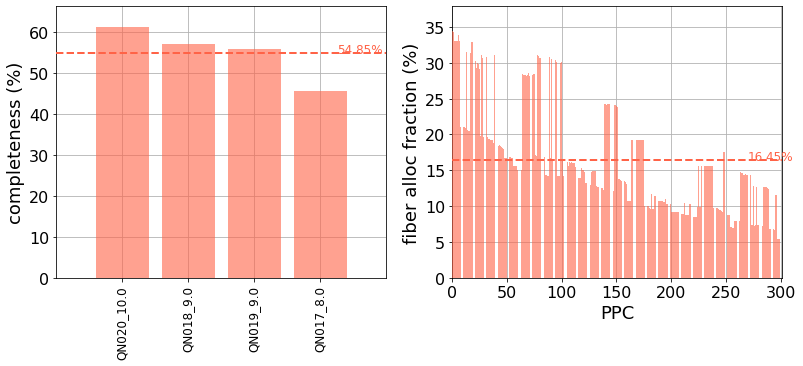

In [25]:
#read sample from local path
readsamp_con={'mode':'local', 'localPath':'input/mock_sim.csv'}

onsourceT_L=900*300 #sec (assuming 300 PPCs given)
onsourceT_M=900*0 #sec (assuming 0 PPCs given)

main(readsamp_con,onsourceT_L,onsourceT_M,False,False,False)

In [ ]:
#read sample from database

sql_t='''
    SELECT 
        T.ob_code, T.ra, T.dec, T.epoch, T.priority, T.effective_exptime, CASE WHEN T.is_medium_resolution = False THEN 'L' ELSE 'M' END AS resolution, T.proposal_id, P.rank, P.grade
    FROM target as T
    JOIN proposal as P on T.proposal_id = P.proposal_id; 
    '''

readsamp_con={'mode':'db', 'dialect':'postgresql','user':'obsproc','pwd':'obsproc','host':'pfsa-db01',\
              'port':'5433','dbname':'targetdb_e2e_test','sql_query':sql_t}

onsourceT_L=900*50 #sec
onsourceT_M=900*0 #sec

main(readsamp_con,onsourceT_L,onsourceT_M,True,False,False)